# Keras MNIST


* Atividade PEL219 - Keras MNIST - Gabriel Melo. Matrícula: 125.304-6

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

I0000 00:00:1773457891.705532    4846 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773457892.025685    4846 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773457893.771686    4846 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

In [3]:

y_train = to_categorical(y_train)

In [4]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000, 10), (10000, 28, 28), (10000,))

In [5]:
model = Sequential() 
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(1280, activation="sigmoid"))
model.add(Dense(640, activation="sigmoid"))
model.add(Dense(10, activation="softmax"))  # digit numbers
model.compile('adam', 'categorical_crossentropy', metrics=['categorical_accuracy'])

/home/melo/code/machine-learning/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1773457899.347713    4846 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1280)           │     1,004,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 640)            │       819,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         6,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,831,050 (6.98 MB)

 Trainable params: 1,831,050 (6.98 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(x=x_train, y=y_train, epochs=10, validation_split=.1)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - categorical_accuracy: 0.8959 - loss: 0.3402 - val_categorical_accuracy: 0.9612 - val_loss: 0.1372
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - categorical_accuracy: 0.9567 - loss: 0.1374 - val_categorical_accuracy: 0.9725 - val_loss: 0.0940
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - categorical_accuracy: 0.9730 - loss: 0.0857 - val_categorical_accuracy: 0.9792 - val_loss: 0.0725
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - categorical_accuracy: 0.9809 - loss: 0.0586 - val_categorical_accuracy: 0.9772 - val_loss: 0.0742
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - categorical_accuracy: 0.9863 - loss: 0.0426 - val_categorical_accuracy: 0.9820 - val_loss: 0.0673
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - categorical_accuracy: 0.9898 - loss: 0.0303 - val_categorical_accuracy: 0.9830 - val_loss: 0.0683
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - categor

## Testing

In [8]:
results = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [9]:
results_class = np.argmax(results, axis=1)

In [10]:
accuracy_score(results_class, y_test), precision_score(results_class, y_test, average="weighted"), recall_score(results_class, y_test, average="weighted"), f1_score(results_class, y_test, average="weighted")

(0.9812, 0.9812361088731552, 0.9812, 0.9811970606420689)

In [11]:
print(classification_report(y_test, results_class))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.97      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.97      0.98      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



<Axes: >

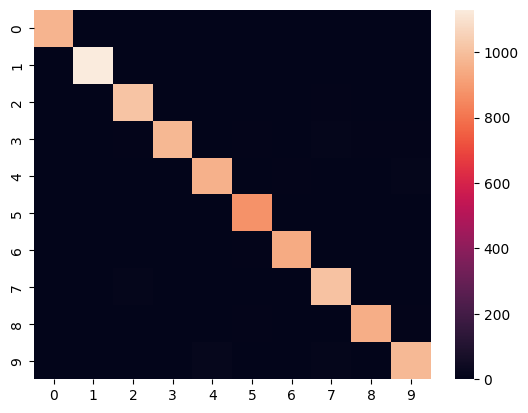

In [12]:
sns.heatmap(confusion_matrix(y_test, results_class))

## Training data

In [13]:
df = pd.DataFrame(history.history)

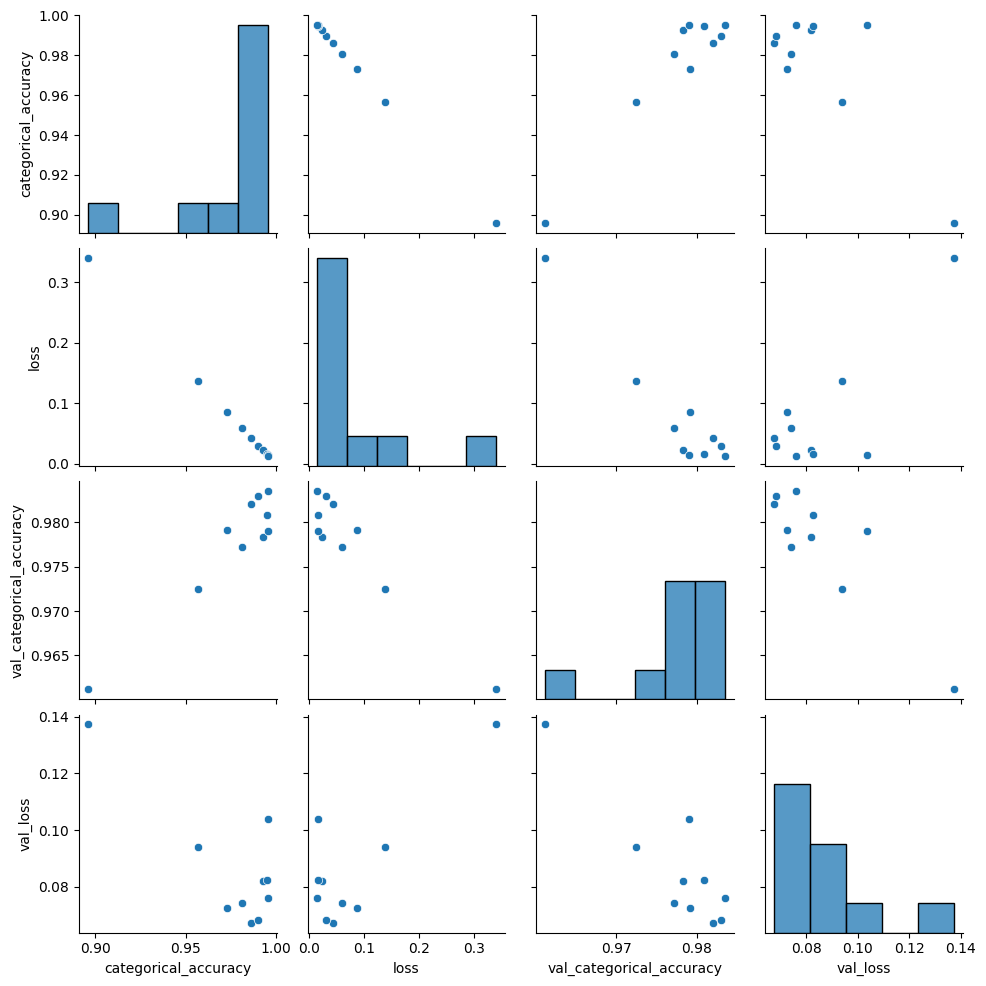

In [14]:
sns.pairplot(df)

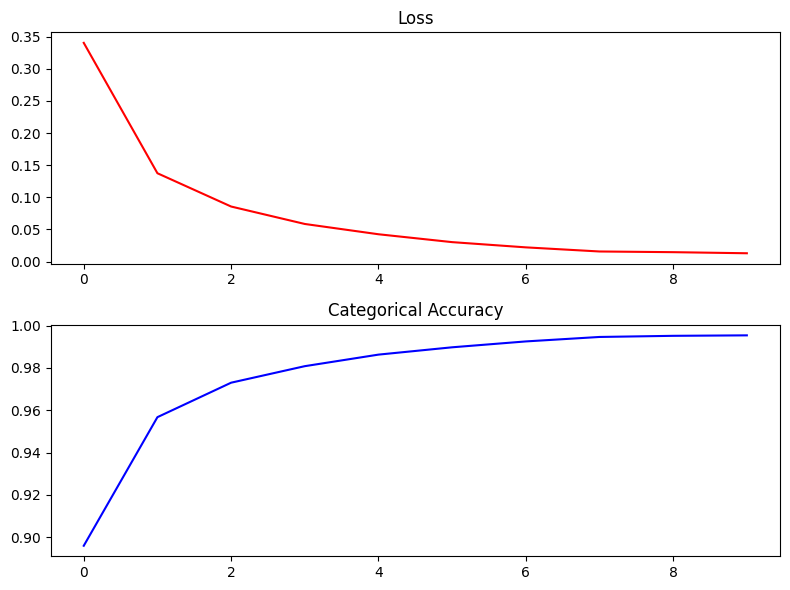

In [15]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

ax[0].plot(df['loss'], color='red')
ax[0].set_title("Loss")

ax[1].plot(df['categorical_accuracy'], color='blue')
ax[1].set_title("Categorical Accuracy")

fig.tight_layout()